# Inventory Trajectory

This notebook loads a saved daily simulation snapshot CSV and plots the inventory trajectory over time.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
snapshot_csv_path = Path("../../data/simulation/m5_foods_3_080_ca_1/forecast_driven_order_up_to/forecast-name_xgboost-recursive-7/default/val_daily_snapshots.csv")
snapshot_csv_path

PosixPath('../../data/simulation/m5_foods_3_080_ca_1/forecast_driven_order_up_to/default/val_daily_snapshots.csv')

In [3]:
snapshots = pd.read_csv(snapshot_csv_path)
snapshots["date"] = pd.to_datetime(snapshots["date"])
snapshots = snapshots.sort_values("date").reset_index(drop=True)
snapshots.head()

,date,on_hand_inventory,outstanding_orders,total_fulfilled_demand,total_unmet_demand,total_holding_cost,total_stockout_cost,total_stockout_days,demand,fulfilled_demand,unmet_demand,stockout_day
0,2014-09-30,33.0,"[{""quantity"": 52.0, ""arrival_date"": ""2014-10-0...",20.0,0.0,3.3,0.0,0,20,20.0,0.0,False
1,2014-10-01,18.0,"[{""quantity"": 52.0, ""arrival_date"": ""2014-10-0...",35.0,0.0,5.1,0.0,0,15,15.0,0.0,False
2,2014-10-02,1.0,"[{""quantity"": 52.0, ""arrival_date"": ""2014-10-0...",52.0,0.0,5.2,0.0,0,17,17.0,0.0,False
3,2014-10-03,0.0,"[{""quantity"": 52.0, ""arrival_date"": ""2014-10-0...",53.0,21.0,5.2,42.0,1,22,1.0,21.0,True
4,2014-10-04,0.0,"[{""quantity"": 52.0, ""arrival_date"": ""2014-10-0...",53.0,47.0,5.2,94.0,2,26,0.0,26.0,True


In [4]:
snapshots[["date", "on_hand_inventory", "demand", "fulfilled_demand", "unmet_demand"]].describe(include="all")

,date,on_hand_inventory,demand,fulfilled_demand,unmet_demand
count,382,382.000000,382.000000,382.000000,382.000000
mean,2015-04-08 12:00:00,42.109948,17.738220,17.109948,0.628272
min,2014-09-30 00:00:00,0.000000,0.000000,0.000000,0.000000
25%,2015-01-03 06:00:00,21.000000,13.000000,13.000000,0.000000
50%,2015-04-08 12:00:00,39.000000,17.000000,17.000000,0.000000
75%,2015-07-12 18:00:00,60.000000,21.000000,21.000000,0.000000
max,2015-10-16 00:00:00,177.000000,43.000000,43.000000,26.000000
std,NaN,29.756818,6.278284,6.590652,2.957802


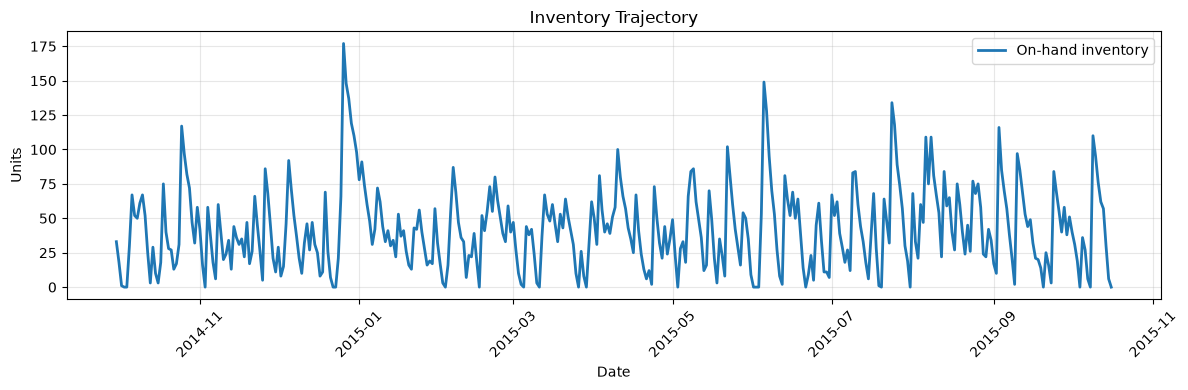

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(snapshots["date"], snapshots["on_hand_inventory"], label="On-hand inventory", linewidth=2)
ax.set_title("Inventory Trajectory")
ax.set_xlabel("Date")
ax.set_ylabel("Units")
ax.grid(True, alpha=0.3)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()

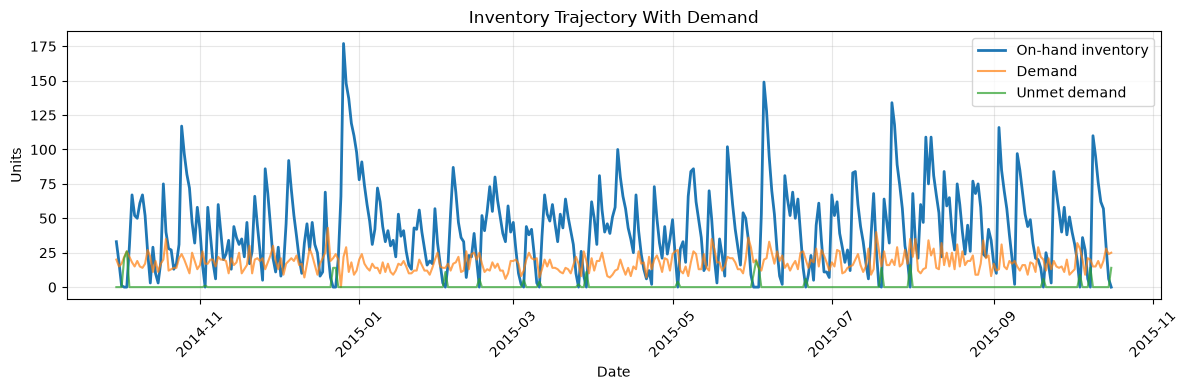

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(snapshots["date"], snapshots["on_hand_inventory"], label="On-hand inventory", linewidth=2)
ax.plot(snapshots["date"], snapshots["demand"], label="Demand", alpha=0.7)
ax.plot(snapshots["date"], snapshots["unmet_demand"], label="Unmet demand", alpha=0.7)
ax.set_title("Inventory Trajectory With Demand")
ax.set_xlabel("Date")
ax.set_ylabel("Units")
ax.grid(True, alpha=0.3)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()